# Exploratory Data Analysis (EDA)

Esse processo segue formalmente os capítulos 2, 3 do livro Forecasting: Principles and Practice, the Pythonic Way. Verifique no link: https://otexts.com/fpppy/

Assim como usa o livro Forecasting Principles and Practice (Aileen Nielsen) e Python for Data Analysis, 3E (https://wesmckinney.com/book/) para apoio teórico e prático.
Demais citações ao decorrer dos códigos.

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Exploração e análise da Série Temporal completa do Porto

## Preliminares

Importações de bibliotecas e funções necessárias

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from fpppy.utils import plot_series
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.graphics.tsaplots import plot_pacf
from scipy import stats

Carregando csv dos dados do porto e verificando tipos de dados para confirmar que a coluna 'data' esteja em datetime

In [3]:
st = pd.read_csv("../data/processed/serietemporal.csv", parse_dates=["data"])

In [4]:
print(st.dtypes)
st.head()

data           datetime64[ns]
acucar                float64
farelo_soja           float64
milho                 float64
outros                float64
graos_soja            float64
porto                 float64
dtype: object


,data,acucar,farelo_soja,milho,outros,graos_soja,porto
0,2005-01-01,581383.455,148641.973,67968.749,1675915.136,107966.285,5027935.933
1,2005-02-01,878015.791,207084.350,11623.584,1709254.262,390955.911,5316604.778
2,2005-03-01,610138.354,186525.305,12014.295,1730293.750,896454.461,5899909.231
3,2005-04-01,764282.986,340274.229,7687.881,1860562.606,858345.463,5850636.302
4,2005-05-01,1007703.226,330537.573,12814.725,2027806.818,1062494.325,6826360.941


Vizualizando em gráfico de série temporal a movimentação total do porto de Santos ao longo dos anos 2005 a 2026.

Note que nessa vizualização podemos ter uma hipótese de que a série segue uma tendência de crescimento e apresenta uma sazonalidade mediante aos picos recorrentes na progressão dos dados.

<small>Hyndman, R.J., Athanasopoulos, G., Garza, A., Challu, C., Mergenthaler, M., & Olivares, K.G. (2025). Forecasting: Principles and Practice, the Pythonic Way. OTexts: Melbourne, Australia.
<small>(2.2 Time plots)

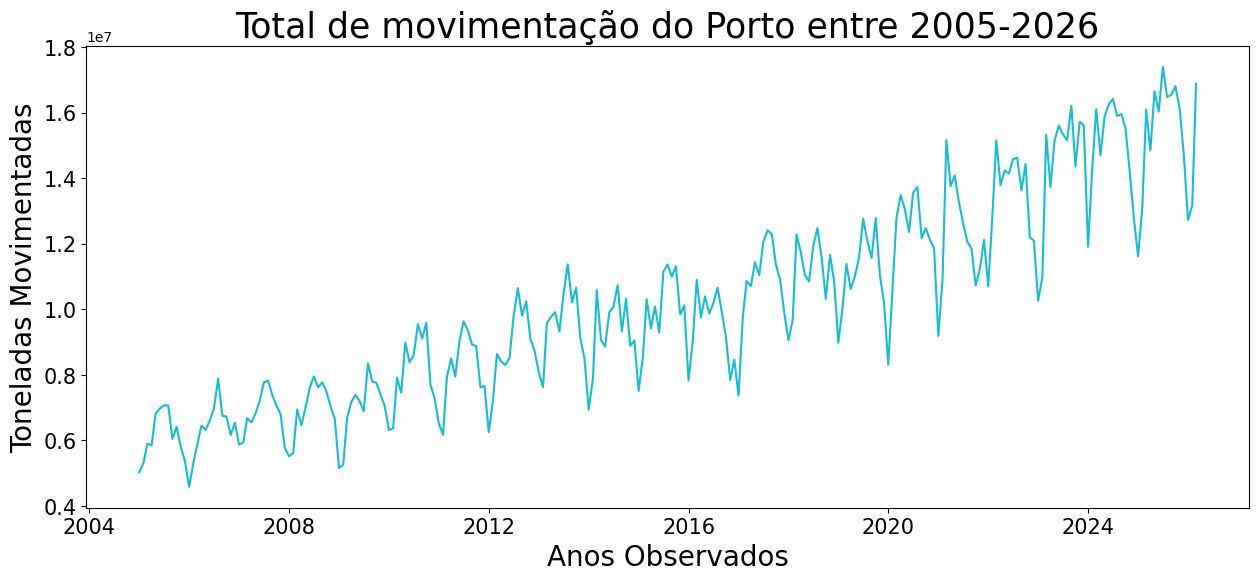

In [5]:
st['unique_id'] = 'porto_santos'
plot_series(
    df=st, id_col='unique_id', time_col='data', target_col='porto',
    xlabel='Anos Observados', ylabel='Toneladas Movimentadas',
    title='Total de movimentação do Porto entre 2005-2026')

In [6]:
st['porto'].describe()

count    2.550000e+02
mean     1.018601e+07
std      3.080890e+06
min      4.588414e+06
25%      7.624833e+06
50%      9.906814e+06
75%      1.214711e+07
max      1.740540e+07
Name: porto, dtype: float64

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Sazonalidade

Explicitando a sazonalidade por isolamento mensal e verificando no gráfico seu comportamento.

<small>Hyndman, R.J., Athanasopoulos, G., Garza, A., Challu, C., Mergenthaler, M., & Olivares, K.G. (2025). Forecasting: Principles and Practice, the Pythonic Way. OTexts: Melbourne, Australia.
<small>(2.5 Seasonal subseries plots)

In [7]:
sazonalidade = st.assign(
    ano = st['data'].dt.year,
    nome_mes = st['data'].dt.month_name(),
    idx_mes = st['data'].dt.month,
)
display(sazonalidade)

,data,acucar,farelo_soja,milho,outros,graos_soja,porto,unique_id,ano,nome_mes,idx_mes
0,2005-01-01,581383.455,148641.973,67968.749,1675915.136,107966.285,5.027936e+06,porto_santos,2005,January,1
1,2005-02-01,878015.791,207084.350,11623.584,1709254.262,390955.911,5.316605e+06,porto_santos,2005,February,2
2,2005-03-01,610138.354,186525.305,12014.295,1730293.750,896454.461,5.899909e+06,porto_santos,2005,March,3
3,2005-04-01,764282.986,340274.229,7687.881,1860562.606,858345.463,5.850636e+06,porto_santos,2005,April,4
4,2005-05-01,1007703.226,330537.573,12814.725,2027806.818,1062494.325,6.826361e+06,porto_santos,2005,May,5
...,...,...,...,...,...,...,...,...,...,...,...
250,2025-11-01,2608045.205,972150.444,2408073.789,3073654.839,1170675.035,1.612665e+07,porto_santos,2025,November,11
251,2025-12-01,1648997.531,719107.585,2594208.417,2975549.057,1012862.467,1.473902e+07,porto_santos,2025,December,12
252,2026-01-01,1561010.948,867668.554,1151919.295,2886656.038,699950.201,1.272810e+07,porto_santos,2026,January,1
253,2026-02-01,1477114.383,625398.725,74968.470,2661940.849,3235398.809,1.317256e+07,porto_santos,2026,February,2


Note que o padrão do porto de safra (Alta Movimentação) e entressafra (Baixa Movimentação) pode ser observado conforme o esperado, safra no meio do ano com pico em julho, e entressafra nos demais meses periféricos de começo e final de ano.

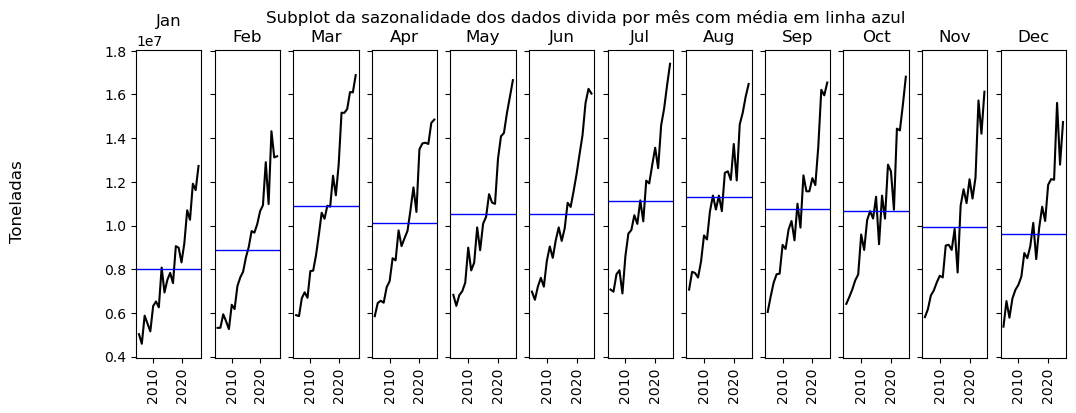

In [8]:
fig, axes = plt.subplots(1, 12, figsize=(12, 4), sharey=True)

for ax, ((_, nome_mes), mes_df) in zip(
        axes, sazonalidade.groupby(['idx_mes', 'nome_mes'])):
    media = mes_df['porto'].mean()
    ax.plot(mes_df['ano'], mes_df['porto'], color='k')
    ax.axhline(media, color='b', linewidth=1)
    ax.set(title=nome_mes[:3], xlabel='')
    ax.tick_params(axis='x', rotation=90)

fig.suptitle('Subplot da sazonalidade dos dados divida por mês com média em linha azul')
fig.supylabel('Toneladas')
fig.show()

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## ACF e testes ADF & KPSS

Para evidenciar que a série histórica do Porto de Santos possui complexidade de tendência-ciclo + sazonalidade, iremos plotar o correlograma da função de autocorrelação (ACF - autocorrelation function).

<small>Hyndman, R.J., Athanasopoulos, G., Garza, A., Challu, C., Mergenthaler, M., & Olivares, K.G. (2025). Forecasting: Principles and Practice, the Pythonic Way. OTexts: Melbourne, Australia.
<small>(2.8 Autocorrelation)

<small> Skipper, S., & Josef, P. (2010). statsmodels: Econometric and statistical modeling with python. 9th Python in Science Conference statsmodels.

<small>Disponível em: www.org/dev/examples/notebooks/generated/stationarity_detrending_adf_kpss.html

In [9]:
acf = sm.tsa.acf(st['porto'], nlags=9, fft=False, bartlett_confint=False)
acf_df = pd.Series(acf, name='ACF').to_frame().rename_axis('lag')
acf_df[1:]

,ACF
lag,
1,0.916207
2,0.861135
3,0.826623
4,0.786397
5,0.758327
6,0.726799
7,0.731335
8,0.737609
9,0.743928


Note que no gráfico da função de autocorrelação os lags demonstram um padrão de redução lenta, devido a tendência, e esse formato "scalopped" devido a sazonalidade.

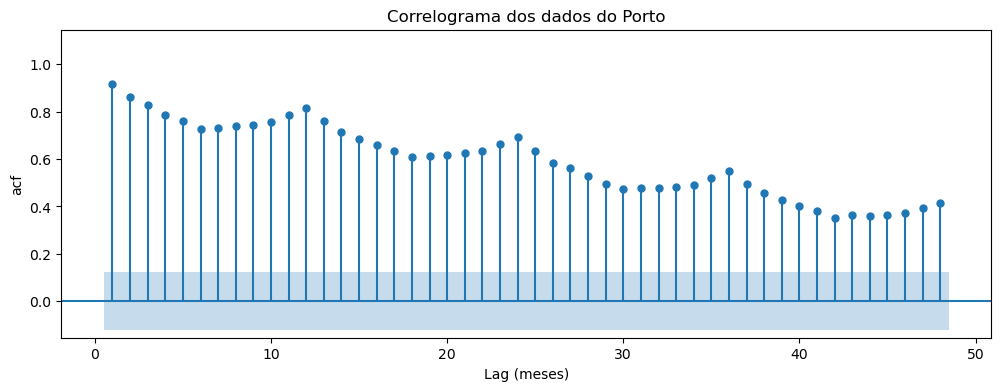

In [10]:
fig, ax = plt.subplots(figsize=(12,4))
plot_acf(st['porto'], lags = 48, ax=ax,
         zero=False, bartlett_confint=False, auto_ylims=True),
ax.set(
    title='Correlograma dos dados do Porto',
    xlabel='Lag (meses)', ylabel='acf',
)
fig.show()

As funções abaixo foram obtidas e adtadas através do site da biblioteca Statsmodel.

<small>Disponível em: www.org/dev/examples/notebooks/generated/stationarity_detrending_adf_kpss.html

In [11]:
def adf_test(timeseries):
    print("Resultados do teste Dickey-Fuller:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Teste estatístico",
            "p-valor",
            "#Lags usados",
            "Numero de observações usadas:",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Valor Crítico (%s)" % key] = value
    print(dfoutput)

In [12]:
def kpss_test(timeseries):
    print("Resultado do teste KPSS:")
    kpsstest = kpss(timeseries, regression="c", nlags=20)
    kpss_output = pd.Series(
        kpsstest[0:3], index=["Teste estatístico", "p-valor", "Lags usados"]
    )
    for key, value in kpsstest[3].items():
        kpss_output["Valor Crítico (%s)" % key] = value
    print(kpss_output)


Executando o teste Augmented Dickey-Fuller

Hipótese nula $ H_0 $: A série possui uma raiz unitária indicando não-estacionariedade.

Hipótese alternativa $ H_1 $: A série é estacionária.

Interpretação: Se $ p-valor < 0.05$, rejeita-se $ H_0 $ indicando estacionariedade.

In [13]:
adf_test(st['porto'])

Resultados do teste Dickey-Fuller:
Teste estatístico                  0.435961
p-valor                            0.982791
#Lags usados                      13.000000
Numero de observações usadas:    241.000000
Valor Crítico (1%)                -3.457779
Valor Crítico (5%)                -2.873609
Valor Crítico (10%)               -2.573202
dtype: float64


Em nosso resultado obtivemos $ p-valor = 0.979537 $ portanto: Não rejeita $ H_0 $, não há evidência suficiente para rejeitar a hipótese de raiz unitária.

Executando o teste Kwiatkowski-Phillips-Schmidt-Shin

Hipótese nula $ H_0 $: A série é estacionaria.

Hipótese alternativa $ H_1 $: A série tem raiz unitária indicando não estacionariedade.

Interpretação: Se $ p-valor < 0.05$, rejeita-se $ H_0 $ indicando não-estacionariedade.

In [14]:
kpss_test(st['porto'])

Resultado do teste KPSS:
Teste estatístico        1.28237
p-valor                  0.01000
Lags usados             20.00000
Valor Crítico (10%)      0.34700
Valor Crítico (5%)       0.46300
Valor Crítico (2.5%)     0.57400
Valor Crítico (1%)       0.73900
dtype: float64


/tmp/ipykernel_32922/3637380387.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpsstest = kpss(timeseries, regression="c", nlags=20)


Em nosso resultado obtivemos $ p-valor = 0.01000 $, portanto: Rejeita-se $ H_0 $, há evidência para rejeitar estacionariedade em nível.

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## Decomposição STL

Separando um novo DataFrame para podermos aplicar a decomposição da série.

<small>Hyndman, R.J., Athanasopoulos, G., Garza, A., Challu, C., Mergenthaler, M., & Olivares, K.G. (2025). Forecasting: Principles and Practice, the Pythonic Way. OTexts: Melbourne, Australia. (3.6 STL decomposition)

In [15]:
display(st)

,data,acucar,farelo_soja,milho,outros,graos_soja,porto,unique_id
0,2005-01-01,581383.455,148641.973,67968.749,1675915.136,107966.285,5.027936e+06,porto_santos
1,2005-02-01,878015.791,207084.350,11623.584,1709254.262,390955.911,5.316605e+06,porto_santos
2,2005-03-01,610138.354,186525.305,12014.295,1730293.750,896454.461,5.899909e+06,porto_santos
3,2005-04-01,764282.986,340274.229,7687.881,1860562.606,858345.463,5.850636e+06,porto_santos
4,2005-05-01,1007703.226,330537.573,12814.725,2027806.818,1062494.325,6.826361e+06,porto_santos
...,...,...,...,...,...,...,...,...
250,2025-11-01,2608045.205,972150.444,2408073.789,3073654.839,1170675.035,1.612665e+07,porto_santos
251,2025-12-01,1648997.531,719107.585,2594208.417,2975549.057,1012862.467,1.473902e+07,porto_santos
252,2026-01-01,1561010.948,867668.554,1151919.295,2886656.038,699950.201,1.272810e+07,porto_santos
253,2026-02-01,1477114.383,625398.725,74968.470,2661940.849,3235398.809,1.317256e+07,porto_santos


In [16]:
st_stl = (
    st[['data', 'porto']]
    .rename(columns={'porto': 'y'}).assign(unique_id='porto')
)
y = st_stl['y'].to_numpy()

In [17]:
display(st_stl)

,data,y,unique_id
0,2005-01-01,5.027936e+06,porto
1,2005-02-01,5.316605e+06,porto
2,2005-03-01,5.899909e+06,porto
3,2005-04-01,5.850636e+06,porto
4,2005-05-01,6.826361e+06,porto
...,...,...,...
250,2025-11-01,1.612665e+07,porto
251,2025-12-01,1.473902e+07,porto
252,2026-01-01,1.272810e+07,porto
253,2026-02-01,1.317256e+07,porto


In [18]:
stl = STL(st_stl['y'], period=12)
res = stl.fit()
dcmp = pd.DataFrame({
    'data' : st_stl['data'],
    'porto' : st_stl['y'],
    'trend' : res.trend,
    'seasonal' : res.seasonal,
    'remainder' : res.resid,
}).reset_index(drop=True)

dcmp.head()

,data,porto,trend,seasonal,remainder
0,2005-01-01,5027935.933,6.137608e+06,-1.148792e+06,39119.779469
1,2005-02-01,5316604.778,6.134246e+06,-6.919524e+05,-125688.510787
2,2005-03-01,5899909.231,6.131009e+06,-2.620652e+05,30965.626603
3,2005-04-01,5850636.302,6.128020e+06,-9.959921e+04,-177784.954720
4,2005-05-01,6826360.941,6.125449e+06,3.895669e+05,311344.711309


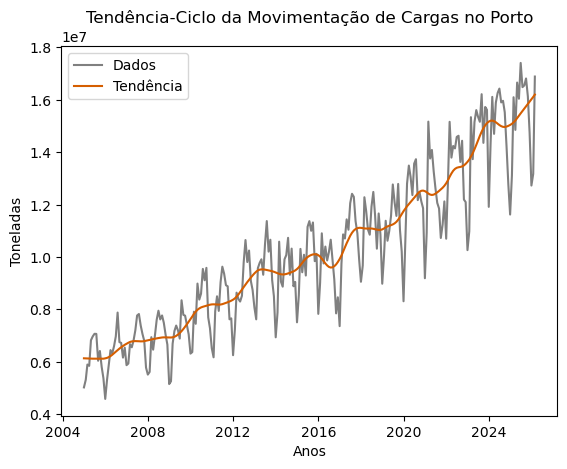

In [19]:
fig, ax = plt.subplots()
sns.lineplot(data=dcmp, x='data', y='porto', color='gray', label='Dados')
sns.lineplot(data=dcmp, x='data', y='trend', color='#D55E00', label='Tendência')

ax.set(
    title='Tendência-Ciclo da Movimentação de Cargas no Porto',
    xlabel='Anos',
    ylabel = 'Toneladas',
)
plt.show()

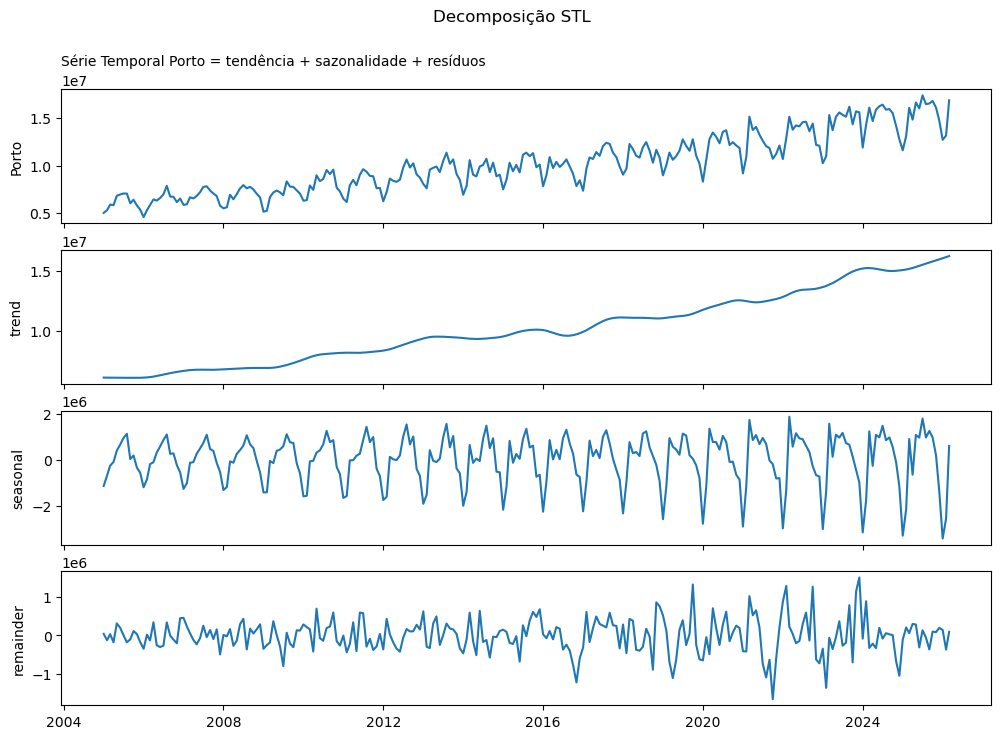

In [20]:
fig, axes = plt.subplots(4,1, sharex=True, figsize=(12,8))
sns.lineplot(data=dcmp, x='data', y='porto', ax=axes[0])
sns.lineplot(data=dcmp, x='data', y='trend', ax=axes[1])
sns.lineplot(data=dcmp, x='data', y='seasonal', ax=axes[2])
sns.lineplot(data=dcmp, x='data', y='remainder', ax=axes[3])
axes[0].set_title('Série Temporal Porto = tendência + sazonalidade + resíduos',
                  size='medium',loc='left')
axes[0].set(ylabel='Porto')
axes[3].set(xlabel='')
fig.suptitle('Decomposição STL')
plt.show()

In [21]:
dcmp.to_csv('../data/processed/st_dcmp')

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Teste de normalidade e PACF da série diferenciada

Como o modelo de Chen FTS é aplicado à série diferenciada ($\Delta y$), é importante analisar as propriedades desta transformação. Adicionalmente, o PACF complementa o ACF na identificação da estrutura autoregressiva.

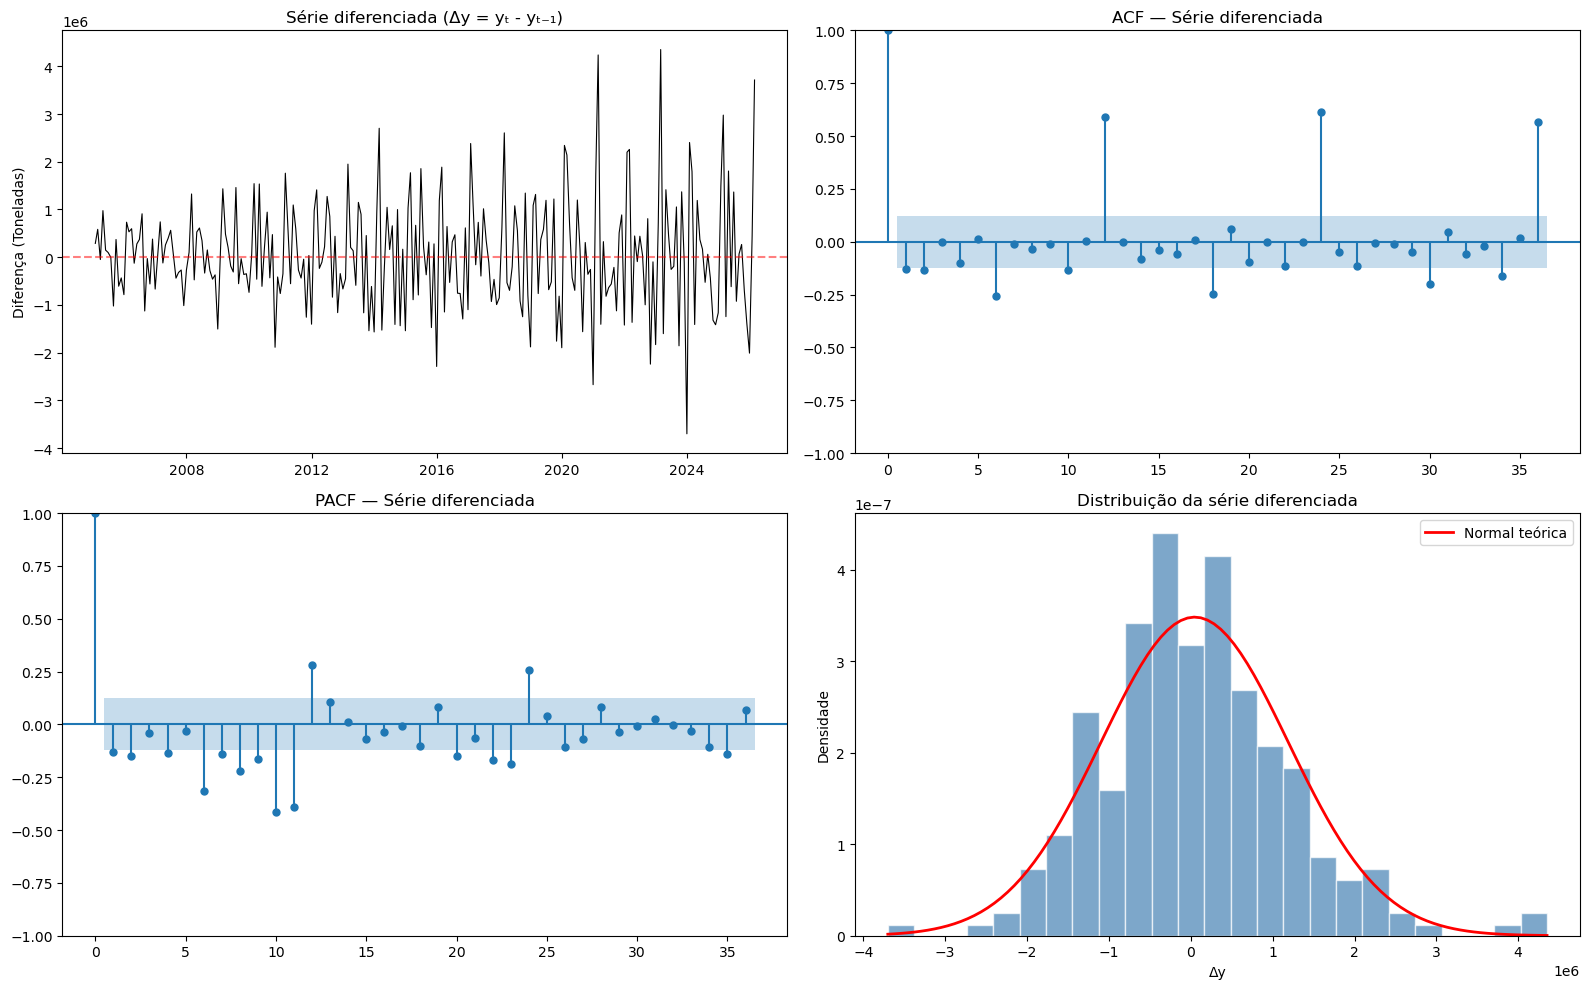

Teste de Shapiro-Wilk:  W = 0.980937, p = 1.745261e-03
Teste de Jarque-Bera:  JB = 26.9270,  p = 1.421916e-06

A série diferenciada NÃO é normalmente distribuída (Shapiro-Wilk rejeita H₀)


In [25]:
# Série diferenciada (primeira diferença)
porto_diff = st.set_index(pd.to_datetime(st['data']))['porto'].diff().dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Série diferenciada
axes[0, 0].plot(porto_diff.index, porto_diff.values, color='black', linewidth=0.8)
axes[0, 0].set_title('Série diferenciada (Δy = yₜ - yₜ₋₁)')
axes[0, 0].set_ylabel('Diferença (Toneladas)')
axes[0, 0].axhline(y=0, color='red', linestyle='--', alpha=0.5)

# 2. ACF da série diferenciada
plot_acf(porto_diff.values, lags=36, ax=axes[0, 1], bartlett_confint=False)
axes[0, 1].set_title('ACF — Série diferenciada')

# 3. PACF da série diferenciada
plot_pacf(porto_diff.values, lags=36, ax=axes[1, 0], method='ywm')
axes[1, 0].set_title('PACF — Série diferenciada')

# 4. Histograma + QQ-plot implícito via normalidade
axes[1, 1].hist(porto_diff.values, bins=25, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[1, 1].set_title('Distribuição da série diferenciada')
axes[1, 1].set_xlabel('Δy')
axes[1, 1].set_ylabel('Densidade')

# Sobrepor curva normal para comparação visual
mu, sigma = porto_diff.mean(), porto_diff.std()
import numpy as np
x_range = np.linspace(porto_diff.min(), porto_diff.max(), 100)
axes[1, 1].plot(x_range, stats.norm.pdf(x_range, mu, sigma), 'r-', linewidth=2, label='Normal teórica')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Testes formais de normalidade
sw_stat, sw_pvalue = stats.shapiro(porto_diff.values)
jb_stat, jb_pvalue = stats.jarque_bera(porto_diff.values)[:2]

print(f"Teste de Shapiro-Wilk:  W = {sw_stat:.6f}, p = {sw_pvalue:.6e}")
print(f"Teste de Jarque-Bera:  JB = {jb_stat:.4f},  p = {jb_pvalue:.6e}")
print()
if sw_pvalue < 0.05:
    print("A série diferenciada NÃO é normalmente distribuída (Shapiro-Wilk rejeita H₀)")
else:
    print("A série diferenciada pode ser normal (Shapiro-Wilk não rejeita H₀)")

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------

# Exploração das colunas dos principais commodities movimentados

Exploração rápida das categorias com maior número de movimentação.

Aqui buscamos entender o comportamento desses commodities que fazem parte das principais movimentações no porto de Santos.

Outros Produtos seria uma categoria relativa, onde pode significar qualquer coisa fora as colunas enuncias no ETL, porém ainda sim faz parte da maior movimentação que o porto de Santos possui.

Conforme podemos observar nos gráficos é uma categoria que apresenta tendência e sazonalidade, através do padrão apresentado no gráfico ACF temos essa noção do padrão "scalloped" que segue a composição de tendência e sazonalidade.

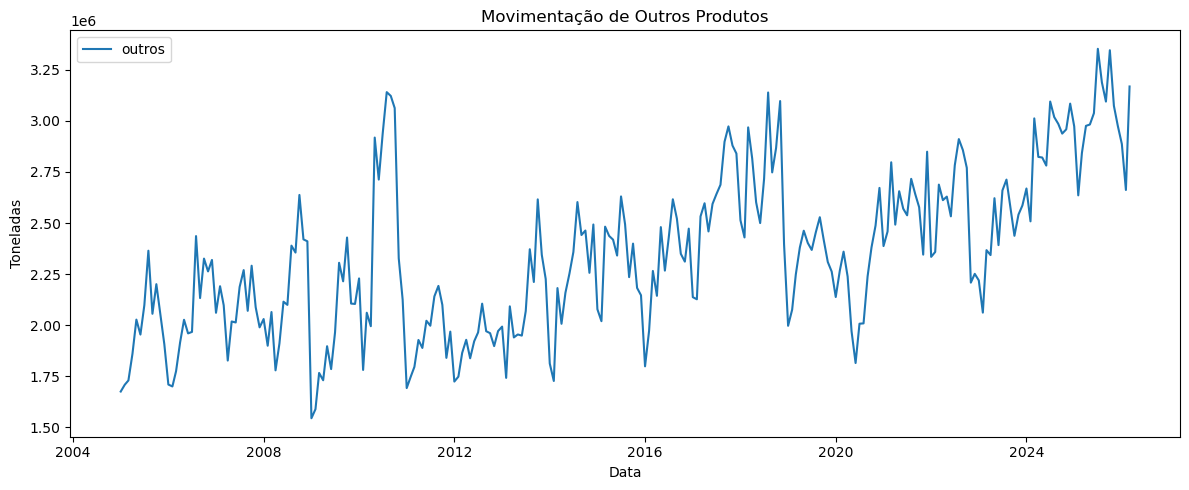

count    2.550000e+02
mean     2.342315e+06
std      3.920172e+05
min      1.545248e+06
25%      2.024583e+06
50%      2.327820e+06
75%      2.614055e+06
max      3.352551e+06
Name: outros, dtype: float64

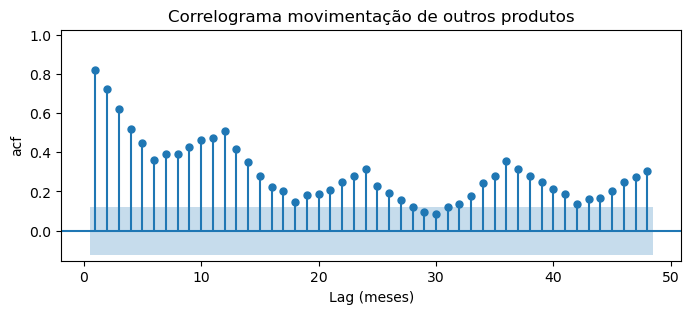

In [6]:
#Gráfico de Linhas
fig, ax = plt.subplots(figsize = (12, 5))
ax.plot(st['data'], st['outros'], linewidth=1.5, label='outros')

ax.set_title('Movimentação de Outros Produtos')
ax.set_xlabel('Data')
ax.set_ylabel('Toneladas')
ax.legend()
plt.tight_layout()
plt.show()

#Gráfico ACF
fig, ax = plt.subplots(figsize=(8,3))
plot_acf(st['outros'], lags = 48, ax=ax,
         zero=False, bartlett_confint=False, auto_ylims=True),
ax.set(
    title='Correlograma movimentação de outros produtos',
    xlabel='Lag (meses)', ylabel='acf',
)
fig.show()

#Estatísticas Básicas
st['outros'].describe()

Açúcar é a segunda maior movimentação do porto de Santos, como podemos ver possui forte sazonalidade indicada pelo gráfico da função de autocorrelação.

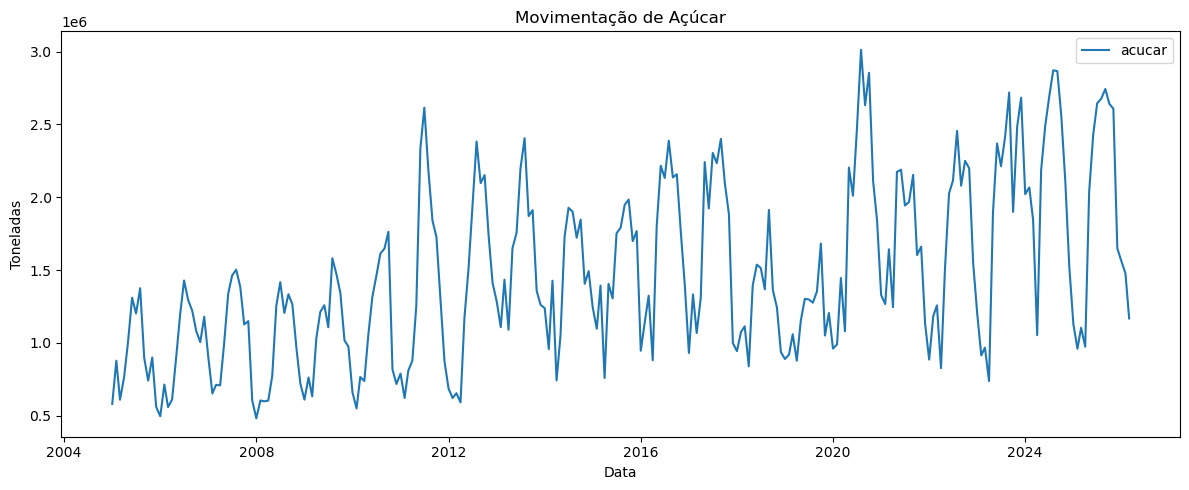

count    2.550000e+02
mean     1.461260e+06
std      6.011829e+05
min      4.825141e+05
25%      9.822744e+05
50%      1.334240e+06
75%      1.912589e+06
max      3.012721e+06
Name: acucar, dtype: float64

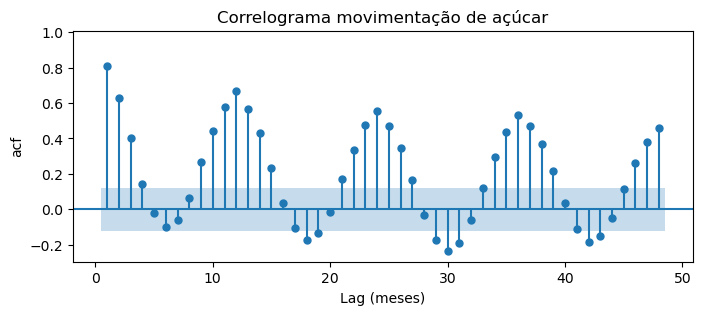

In [7]:
#Gráfico de linhas
fig, ax = plt.subplots(figsize = (12, 5))
ax.plot(st['data'], st['acucar'], linewidth=1.5, label='acucar')

ax.set_title('Movimentação de Açúcar')
ax.set_xlabel('Data')
ax.set_ylabel('Toneladas')
ax.legend()
plt.tight_layout()
plt.show()

#Gráfico ACF
fig, ax = plt.subplots(figsize=(8,3))
plot_acf(st['acucar'], lags = 48, ax=ax,
         zero=False, bartlett_confint=False, auto_ylims=True),
ax.set(
    title='Correlograma movimentação de açúcar',
    xlabel='Lag (meses)', ylabel='acf',
)
fig.show()

#EStatísticas Básicas
st['acucar'].describe()

A movimentação de grãos de soja é o terceiro na lista de maiores movimentações e esse é o que mais evidencia a safra, podemos reparar os picos frequentes anuais e sempre no meio do ano. Já o gráfico ACF demonstra-se como o anterior indicando a forte presença sazonal. A diferença notável desse para o gráfico anterior é que o menor ruído que essa movimentação leva.

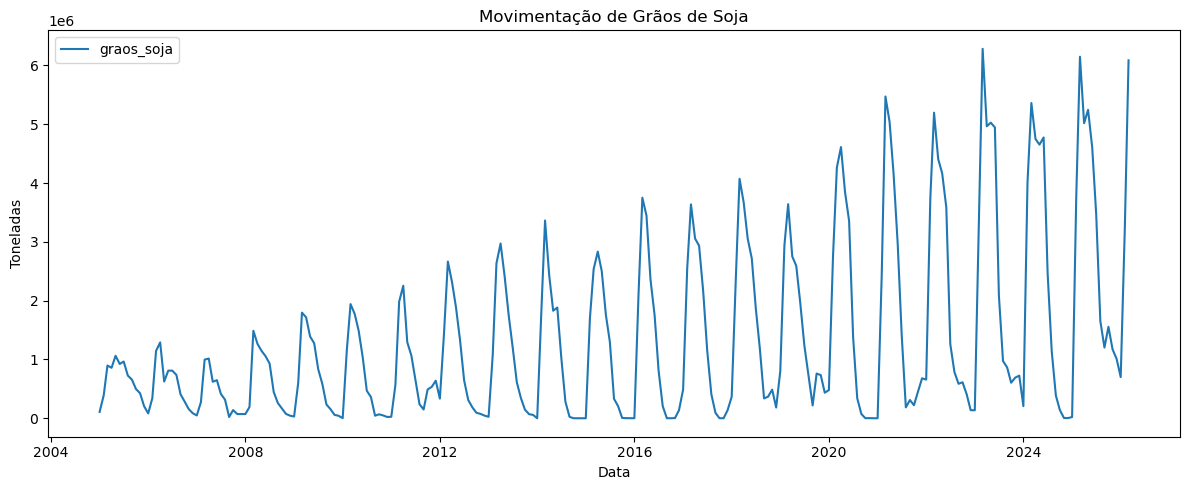

count    2.550000e+02
mean     1.363630e+06
std      1.514183e+06
min      0.000000e+00
25%      1.985515e+05
50%      7.361578e+05
75%      2.036550e+06
max      6.282631e+06
Name: graos_soja, dtype: float64

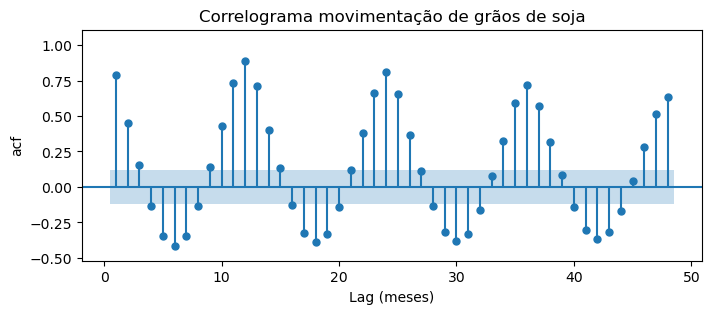

In [8]:
#Gráfico de Linhas
fig, ax = plt.subplots(figsize = (12, 5))
ax.plot(st['data'], st['graos_soja'], linewidth=1.5, label='graos_soja')

ax.set_title('Movimentação de Grãos de Soja')
ax.set_xlabel('Data')
ax.set_ylabel('Toneladas')
ax.legend()
plt.tight_layout()
plt.show()

#Gráfico ACF
fig, ax = plt.subplots(figsize=(8,3))
plot_acf(st['graos_soja'], lags = 48, ax=ax,
         zero=False, bartlett_confint=False, auto_ylims=True),
ax.set(
    title='Correlograma movimentação de grãos de soja',
    xlabel='Lag (meses)', ylabel='acf',
)
fig.show()

#Estatísticas Básicas
st['graos_soja'].describe()

Movimentação de milho como um dos principais commodities do porto também é característica como grãos de soja, padrão de sazonalidade forte indicado.

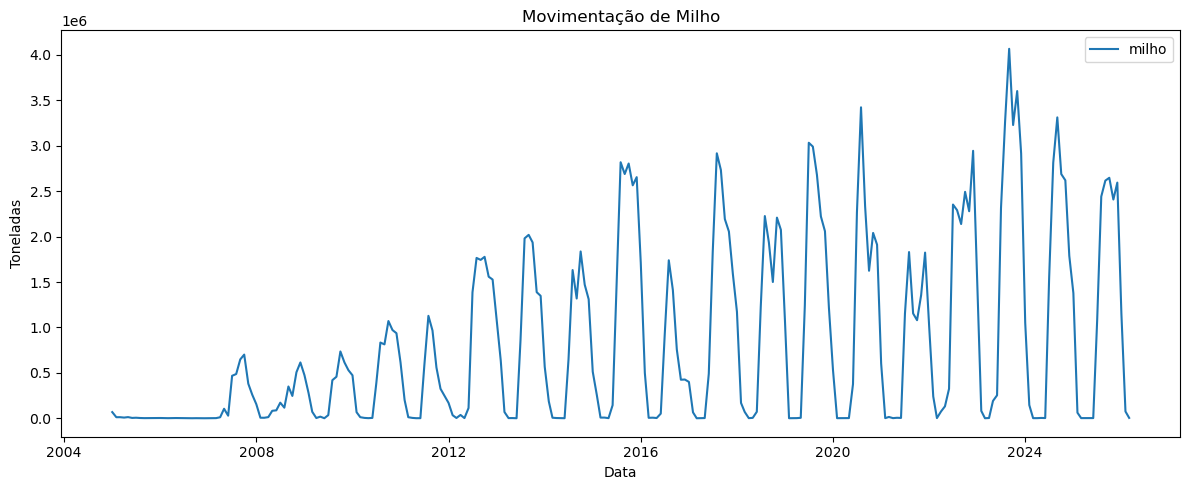

count    2.550000e+02
mean     8.269463e+05
std      9.966819e+05
min      2.742620e+02
25%      4.177020e+03
50%      3.753924e+05
75%      1.501717e+06
max      4.067174e+06
Name: milho, dtype: float64

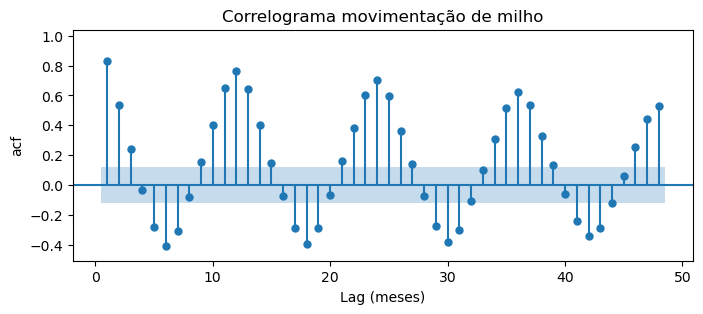

In [9]:
#Gráfico de Linhas
fig, ax = plt.subplots(figsize = (12, 5))
ax.plot(st['data'], st['milho'], linewidth=1.5, label='milho')

ax.set_title('Movimentação de Milho')
ax.set_xlabel('Data')
ax.set_ylabel('Toneladas')
ax.legend()
plt.tight_layout()
plt.show()

#Gráfico ACF
fig, ax = plt.subplots(figsize=(8,3))
plot_acf(st['milho'], lags = 48, ax=ax,
         zero=False, bartlett_confint=False, auto_ylims=True),
ax.set(
    title='Correlograma movimentação de milho',
    xlabel='Lag (meses)', ylabel='acf',
)
fig.show()

#Estatísticas Básicas
st['milho'].describe()

Nessa categoria voltamos a observar o mesmo que na coluna de 'Outros Produtos' porém dessa vez sem ser genérico é especificamente Farelo de Soja, indicando uma tendência de crescimento e um padrão mais suave no gráfico ACF.

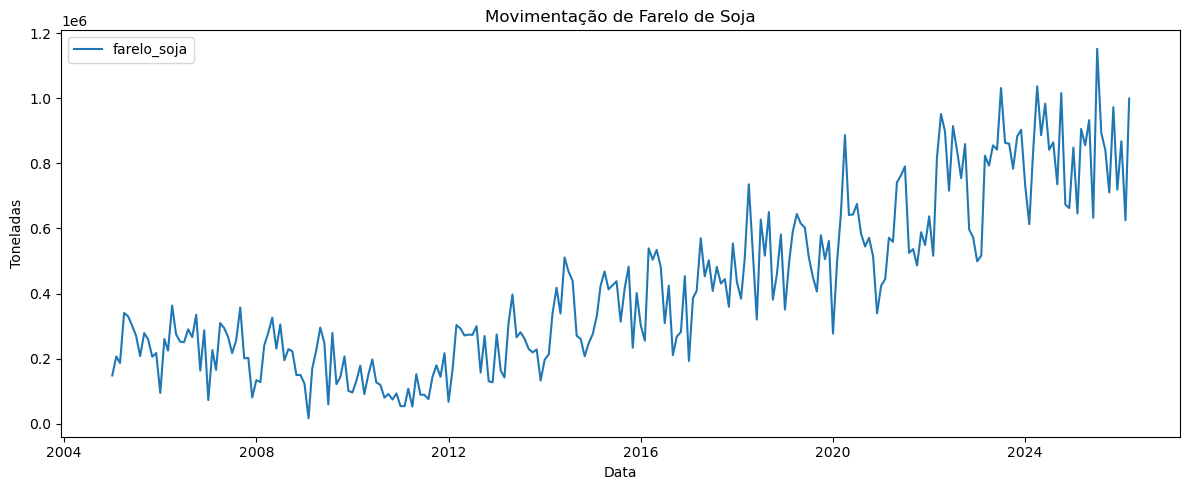

count    2.550000e+02
mean     4.209101e+05
std      2.576425e+05
min      1.723588e+04
25%      2.184935e+05
50%      3.509935e+05
75%      5.828933e+05
max      1.151501e+06
Name: farelo_soja, dtype: float64

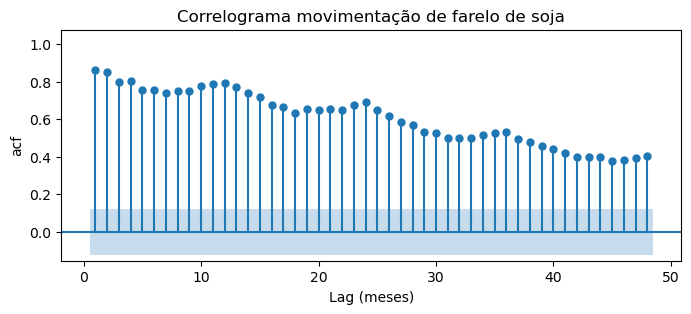

In [10]:
#Gráfico de Linha
fig, ax = plt.subplots(figsize = (12, 5))
ax.plot(st['data'], st['farelo_soja'], linewidth=1.5, label='farelo_soja')

ax.set_title('Movimentação de Farelo de Soja')
ax.set_xlabel('Data')
ax.set_ylabel('Toneladas')
ax.legend()
plt.tight_layout()
plt.show()

#Gráfico ACF
fig, ax = plt.subplots(figsize=(8,3))
plot_acf(st['farelo_soja'], lags = 48, ax=ax,
         zero=False, bartlett_confint=False, auto_ylims=True),
ax.set(
    title='Correlograma movimentação de farelo de soja',
    xlabel='Lag (meses)', ylabel='acf',
)
fig.show()

#Estatísticas Básicas
st['farelo_soja'].describe()

-------------------------------------------------------------------------------------------------------------------------------------------------------------------------